# PANDAPROSUMER EXAMPLE: HEAT PUMP WITH HEAT STRATIFIED STORAGE

## DESCRIPTION:
This example demonstrates how to create a single supervisor controller in pandaprosumer and use it to manage the parameters of other controllers within a prosumer. In this example, the supervisor controls a heat pump and a gas boiler.
 If the gas price is very low, the gas boiler is prioritized. If the gas price is not low, the heat pump is prioritized. If the gas price is extremely high, the gas boiler is turned off—even if the heat pump cannot meet the full demand. The demand and source temperature data is read from an Excel file and stored in pandas dataframe. It includes the information about the power required by the consumer and source temperature at each time step.


![title](img/supervisor.png)

## Glossary:
- Network: A configuration of connected energy generators and energy consumers
- Element: A single energy generator or a single energy consumer
- Controller: The logic of an element that defines its behaviour and its limits
- Prosumer/Container: A pandaprosumer data structure that holds data related to elements and their controllers.
- Const Profile Controller: The initial controller in the network that interacts with other element controllers; it also manages external data via time series.
- Supervisor: A controller that can modify the parameters of other controllers and elements within the prosumer during the calculation process.
- Map / mapping: A connection between two controllers that specifies what information is exchanged between the corresponding elements.

## Network design philosophy:
In pandaprosumer, a system's component is represented by a network element. Each element is assigned a container and its own element controller. A container is a structure that contains the component's configuration data (static input data), which can include information that will not change in the analysis such as size, nominal power, efficiency, etc. The behaviour of an element is governed by its controller. Connections between elements are defined in maps, which couple output parameters of one controller to the input parameter of a controller of a connected element. The network is managed by a controller called ConstProfileController. This controller is connected to all element controllers and manages dynamic input data from external sources (e.g. Excel file). For each time step it distributes the dynamic input data to the relevant element controllers.

# 1 - INPUT DATA:
First let's import libraries required for data management.

In [117]:
import pandas as pd
from pandapower.timeseries.data_sources.frame_data import DFData

from pandaprosumer import create_controlled_supervisor, CombiningRules, Supervisor

Next we need to define properties of the heat pump which are treated as static input data, i.e. data (characteristics) that don't change during an analysis. In this case the properties for the heat pump are :

- `carnot_efficiency`: The efficiency of the heat pump relative to the Carnot cycle (dimensionless, between 0 and 1).
- `pinch_c`: The pinch point temperature difference (°C), which represents the minimum temperature difference in the heat exchanger.
- `delta_t_evap_c`: The temperature difference at the evaporator (°C).
- `max_p_comp_kw`: The maximum compressor power (kW), which limits the heat pump's capacity.
- `name`: A label identifying the heat pump.


Next, we define the properties of the **gas boiler (gb)**

- `max_q_kw`:  Maximal heat power of the boiler [kW]
- `name`: A label for the gas boiler.

 While these arguments are generally optional, in our specific case they are required in order to fully configure the heat exchanger. Other optional arguments are also available for more advanced configurations.



In [118]:
gb_params = {'max_q_kw': 500,
             'name':'gas_boiler'}
hp_params = {"carnot_efficiency": 0.5,
             "pinch_c": 0,
             "delta_t_evap_c": 5,
             "max_p_comp_kw": 200,
             "name":'air_water_heat_pump'}
hd_params = {"name": 'heat_consumer'}

We define the analysis time series.

In [119]:
start = '2020-01-01 00:00:00'
end = '2020-01-01 23:59:59'
time_resolution_s = 900

Now we import our demand data and transform it into an appropriate DFData object. All data of an individual element is stored in a dedicated DFData object.

In [120]:
import sys
import os

current_directory = os.getcwd()
parent_directory = os.path.dirname(current_directory)
sys.path.append(parent_directory)

demand_data = pd.read_excel('data/hp_data_supervised.xlsx')

dur = pd.date_range(start=start, end=end, freq='900s',tz='utc')
demand_data.index = dur
demand_input = DFData(demand_data)
demand_input.df.head(10)

,t_air,demand_power,t_feed_demand_c,t_return_demand_c,gas_price
2020-01-01 00:00:00+00:00,25,0,80,20,0.05
2020-01-01 00:15:00+00:00,25,0,80,20,0.05
2020-01-01 00:30:00+00:00,25,0,80,20,0.05
2020-01-01 00:45:00+00:00,25,0,80,20,0.05
2020-01-01 01:00:00+00:00,25,0,80,20,0.05
2020-01-01 01:15:00+00:00,25,500,80,20,0.05
2020-01-01 01:30:00+00:00,25,500,80,20,0.05
2020-01-01 01:45:00+00:00,25,500,80,20,0.05
2020-01-01 02:00:00+00:00,25,321,80,20,0.05
2020-01-01 02:15:00+00:00,25,321,80,20,0.05


We can plot the evolution of the demand from the Excel file.

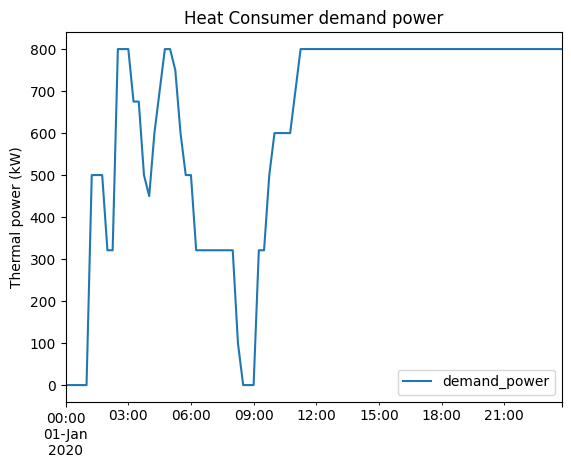

In [121]:
import matplotlib.pyplot as plt

demand_input.df.plot(y='demand_power')
plt.title("Heat Consumer demand power")
plt.ylabel("Thermal power (kW)")
plt.show()

We can plot the evolution of the price of the gas from the Excel file.

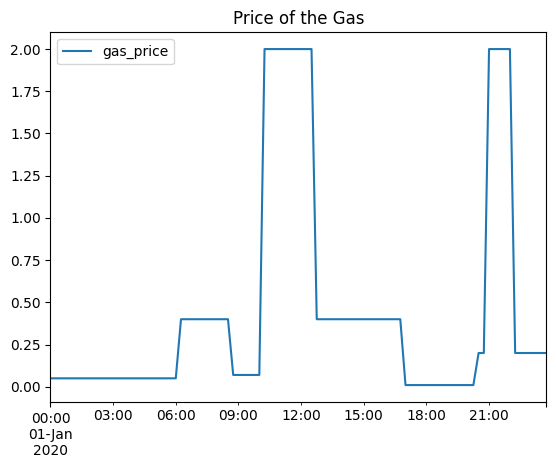

In [122]:
import matplotlib.pyplot as plt

demand_input.df.plot(y='gas_price')
plt.title("Price of the Gas")
plt.ylabel("")
plt.show()

# 2 - CREATING ELEMENTS OF THE NETWORK:
In this example, the network is made up of four elements: a supervisor, two source and a consumer. The source is represented by a heat pump or a gas boiler and the consumer is modelled by a single heat demand element.

We begin by defining an empty prosumer container object and then add the different elements and their respective controllers to it.

In [123]:
from pandaprosumer.create import create_empty_prosumer_container

prosumer = create_empty_prosumer_container()


Then we define the period of the analysis using input data about the analysis of time and also timezone and period name.

In [124]:
from pandaprosumer.create import create_period

period_id = create_period(prosumer, time_resolution_s, start, end, 'utc', 'default')

Now we can create the controllers connected to their respective containers and data. We also define the topology of the network by setting the elements' priority. In this example, the network has a linear configuration (the direction of energy flow goes in one direction), so only the order parameter is set:

- The const profile controller is always the first element in the network and is the only one that reads data from external sources (order 0, level 0),
- The supervisor : order 0, level 2,
- the heat pump controller is the third element (order 0, level 2) in the network,
- The gas boiler order 1, level 2,
- The final order is the demand (order 2, level 1).

We begin by creating the Const Profile Controller.

In [125]:
from pandaprosumer.create_controlled import create_controlled_const_profile

cp_input_columns = ["t_air", "demand_power", "t_feed_demand_c", "t_return_demand_c","gas_price"]
cp_result_columns = ["t_evap_in_c", "qdemand_kw", "t_feed_demand_c", "t_return_demand_c","gas_price"]
cp_controller_index = create_controlled_const_profile(prosumer, cp_input_columns, cp_result_columns, demand_input, period_id, level=0, order=0)

We now define the Supervisor Controller. For now, this supervisor is empty and has no effect on the prosumer. We will add rules and actions after creating the other controllers and completing the mappings.

In [126]:
supervisor_index = create_controlled_supervisor(prosumer, input_columns=['gas_price'], period=period_id, level=1, order=0)
supervisor_object = prosumer.controller.iloc[supervisor_index].object

The Heat Pump, Gas Boiler and Heat Demand controllers are now created.

Note that the "order" parameter of the controllers will define in which order there are executed, effectively defining a merit order between the two available heat sources.

The Heat Pump and the Electric Boiler have both to be executed before the Heat Demand, thus have lower orders.

We want the Heat Pump to be the main source of heat to supply the demand, and the Electric Boiler to be used only during the peak demand. To do so, we also ensure that the order of the Heat Pump controller is lower than the order of the Electric Boiler controller.

In [127]:
from pandaprosumer.create_controlled import create_controlled_heat_pump,create_controlled_gas_boiler, create_controlled_heat_demand

hp_controller_index = create_controlled_heat_pump(prosumer, period=period_id, level=2, order=0, **hp_params)
gb_controller_index = create_controlled_gas_boiler(prosumer, period=period_id, level=2, order=1, **gb_params)
hd_controller_index = create_controlled_heat_demand(prosumer, period=period_id, level=2, order = 2,**hd_params)

# 4 - CREATING CONNECTIONS (MAPS) BETWEEN THE CONTROLLERS:
Network configuration

For each controller we define how it is connected to other controllers.



In [128]:
from pandaprosumer.mapping import GenericMapping
from pandaprosumer.mapping import FluidMixMapping

CONNECTION CONST PROFILE CONTROLLER ---> HEAT PUMP:

The connection from the Const Profile Controller to the Heat Pump Controller enables the heat pump to access the t_air column from the input time series dataset.

In [129]:
GenericMapping(prosumer,
               initiator_id=cp_controller_index,
               initiator_column="t_evap_in_c",
               responder_id=hp_controller_index,
               responder_column="t_evap_in_c",
               order=0)

CONNECTION CONST PROFILE CONTROLLER ---> HEAT DEMAND:

The connection from the Const Profile Controller to the Heat Demand Controller enables the heat demand to access the demand_power, t_feed_demand_c, t_return_demand_c columns from the input time series dataset.

The order=1 in this mapping between ConstProfileController and HeatDemandController defines the sequence in which this mapping is applied, relative to other mappings from the ConstProfileController. It ensures that this mapping happens in the correct order if there are multiple mappings from the same initiator controller.

This mapping order is separate from the controller execution order, which defines when the controllers themselves are executed during each simulation step. The order=1 ensures the data flows in the intended sequence without affecting the overall controller run order.

In [130]:
GenericMapping(prosumer,
               initiator_id=cp_controller_index,
               initiator_column=["qdemand_kw", "t_feed_demand_c", "t_return_demand_c"],
               responder_id=hd_controller_index,
               responder_column=["q_demand_kw", "t_feed_demand_c", "t_return_demand_c"],
               order=1)

CONNECTION CONST PROFILE CONTROLLER -> Supervisor
The connection from the Const Profile Controller to the supervisor Controller enables the supervisor to access the gas_price column from the input time series dataset.

In [131]:
GenericMapping(prosumer,
               initiator_id=cp_controller_index,
               initiator_column=["gas_price"],
               responder_id=supervisor_index,
               responder_column=["gas_price"],
               order=2)

CONNECTION GAS BOILER ---> HEAT DEMAND:

The connection between the Gas Boiler Controller and the Heat Demand Controller allows the electric boiler to read the remaining heat demand level and use it as an input for its own calculations. Instead of a generic mapping, a fluid mix mapping is used—this is necessary because the parameters being exchanged, such as mass flow, are dynamic and not static.

In [132]:
first_mapping = FluidMixMapping(prosumer,
                                initiator_id=gb_controller_index,
                                responder_id=hd_controller_index,
                                order=0)

HEAT PUMP ---> HEAT DEMAND:


The connection between the Heat Pump Controller and the Heat Demand Controller allows the heat pump to read the heat demand level and use it as an input for its own calculations. Instead of a generic mapping, a fluid mix mapping is used—this is necessary because the parameters being exchanged, such as mass flow, are dynamic and not static.

In [133]:
second_mapping = FluidMixMapping(prosumer,
                                 initiator_id=hp_controller_index,
                                 responder_id=hd_controller_index,
                                 order=0)

# 5 - RULES:

Now we can define the rules and the action that we be managed with the supervisor and add them to the supervisor object. If the price of the gas is below 0.1 euro/kwh then we can use the gas boiler in priority. If the gas price is between 0.1 and 1 euro/kWh then heat pump in priority else do not use the gas boiler.

In [134]:
from pandaprosumer.supervisor.rule import Rule

rule1 = Rule(controlled_columns ='gas_price',
             operator_str = '<=',
             threshold_value = 0.1,
             controller = [gb_controller_index,hp_controller_index],
             attr = ['order', 'order'],
             new_value = [0, 1])

combiningrule2 = CombiningRules([Rule('gas_price', '>', 0.1, gb_controller_index, 'order', 1),
                                 Rule('gas_price', '<=', 1, hp_controller_index, 'order', 0)], "AND")

#if gas_price >1 then in_service = False (turn off the gas boiler) but we have to make sure that the order of the demand controller is set to 1
# and the order of the heat pump controller is set to 0
rule3 = Rule('gas_price',
             '>',
             1,
             controller = [gb_controller_index,hd_controller_index,hp_controller_index],
             attr = ['in_service', 'order', 'order'],
             new_value = [False, 1 , 0],
             value_if_false = [True, 2, None])

supervisor_object.add_rule(rule1)
supervisor_object.add_rule(combiningrule2)
supervisor_object.add_rule(rule3)

# 6 - RUNNING THE ANALYSIS:
We can now run the analysis with the input data defined above.

In [135]:
from pandaprosumer.run_time_series import run_timeseries

run_timeseries(prosumer, period_id, verbose=True)

100%|██████████| 96/96 [00:02<00:00, 43.17it/s]


# 7 - PRINTING AND PLOTTING RESULTS:
All the results of the timeseries analysis are available in the prosumer.time_series dataframe

In [136]:
prosumer.time_series

,name,element,element_index,period_index,data_source
0,air_water_heat_pump,heat_pump,0.0,0.0,DFData
1,gas_boiler,gas_boiler,0.0,0.0,DFData
2,heat_consumer,heat_demand,0.0,0.0,DFData


Before plotting we have to look at the resulting dataframe to see which quantity (column) do we want to plot.
Access the results of the heat pump, gas boiler and heat demand:

In [137]:
prosumer.time_series.data_source.loc[0].df.head(10)

,q_cond_kw,p_comp_kw,q_evap_kw,cop,mdot_cond_kg_per_s,t_cond_in_c,t_cond_out_c,mdot_evap_kg_per_s,t_evap_in_c,t_evap_out_c
2020-01-01 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,20.0,20.0,0.0,25.0,25.0
2020-01-01 00:15:00+00:00,0.0,0.0,0.0,0.0,0.0,20.0,20.0,0.0,25.0,25.0
2020-01-01 00:30:00+00:00,0.0,0.0,0.0,0.0,0.0,20.0,20.0,0.0,25.0,25.0
2020-01-01 00:45:00+00:00,0.0,0.0,0.0,0.0,0.0,20.0,20.0,0.0,25.0,25.0
2020-01-01 01:00:00+00:00,0.0,0.0,0.0,0.0,0.0,20.0,20.0,0.0,25.0,25.0
2020-01-01 01:15:00+00:00,0.0,0.0,0.0,0.0,0.0,80.0,80.0,0.0,25.0,25.0
2020-01-01 01:30:00+00:00,0.0,0.0,0.0,0.0,0.0,80.0,80.0,0.0,25.0,25.0
2020-01-01 01:45:00+00:00,0.0,0.0,0.0,0.0,0.0,80.0,80.0,0.0,25.0,25.0
2020-01-01 02:00:00+00:00,0.0,0.0,0.0,0.0,0.0,80.0,80.0,0.0,25.0,25.0
2020-01-01 02:15:00+00:00,0.0,0.0,0.0,0.0,0.0,80.0,80.0,0.0,25.0,25.0


In [138]:
prosumer.time_series.data_source.loc[1].df.head(10)

,q_kw,mdot_kg_per_s,t_in_c,t_out_c,mdot_gas_kg_per_s
2020-01-01 00:00:00+00:00,0.0,0.000000,20.0,20.0,0.00000
2020-01-01 00:15:00+00:00,0.0,0.000000,20.0,20.0,0.00000
2020-01-01 00:30:00+00:00,0.0,0.000000,20.0,20.0,0.00000
2020-01-01 00:45:00+00:00,0.0,0.000000,20.0,20.0,0.00000
2020-01-01 01:00:00+00:00,0.0,0.000000,20.0,20.0,0.00000
2020-01-01 01:15:00+00:00,500.0,1.992880,20.0,80.0,0.01000
2020-01-01 01:30:00+00:00,500.0,1.992880,20.0,80.0,0.01000
2020-01-01 01:45:00+00:00,500.0,1.992880,20.0,80.0,0.01000
2020-01-01 02:00:00+00:00,321.0,1.279429,20.0,80.0,0.00642
2020-01-01 02:15:00+00:00,321.0,1.279429,20.0,80.0,0.00642


In [139]:
prosumer.time_series.data_source.loc[2].df.head(10)

,q_received_kw,q_uncovered_kw,mdot_kg_per_s,t_in_c,t_out_c
2020-01-01 00:00:00+00:00,0.0,0.000000e+00,0.000000,20.0,20.0
2020-01-01 00:15:00+00:00,0.0,0.000000e+00,0.000000,20.0,20.0
2020-01-01 00:30:00+00:00,0.0,0.000000e+00,0.000000,20.0,20.0
2020-01-01 00:45:00+00:00,0.0,0.000000e+00,0.000000,20.0,20.0
2020-01-01 01:00:00+00:00,0.0,0.000000e+00,0.000000,20.0,20.0
2020-01-01 01:15:00+00:00,500.0,5.684342e-14,1.992880,80.0,20.0
2020-01-01 01:30:00+00:00,500.0,5.684342e-14,1.992880,80.0,20.0
2020-01-01 01:45:00+00:00,500.0,5.684342e-14,1.992880,80.0,20.0
2020-01-01 02:00:00+00:00,321.0,0.000000e+00,1.279429,80.0,20.0
2020-01-01 02:15:00+00:00,321.0,0.000000e+00,1.279429,80.0,20.0


Alternatively, if the elements have unique names, we can change the indexing of the result dataframe to use the name of the elements as index and access the results more directly.

In [140]:
res_df = prosumer.time_series.copy()
res_df.set_index('name', inplace=True)

In [141]:
res_df

,element,element_index,period_index,data_source
name,,,,
air_water_heat_pump,heat_pump,0.0,0.0,DFData
gas_boiler,gas_boiler,0.0,0.0,DFData
heat_consumer,heat_demand,0.0,0.0,DFData


We can plot the Heat Pump provided heat power and consumed electric power.

The maximal power of the heat pump is limited as defined in the heat pump element.

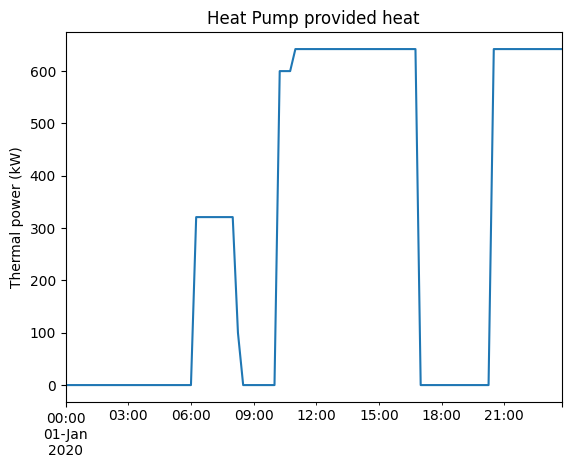

In [142]:
res_df.data_source.loc['air_water_heat_pump'].df.q_cond_kw.plot()
plt.title("Heat Pump provided heat")
plt.ylabel("Thermal power (kW)")
plt.show()

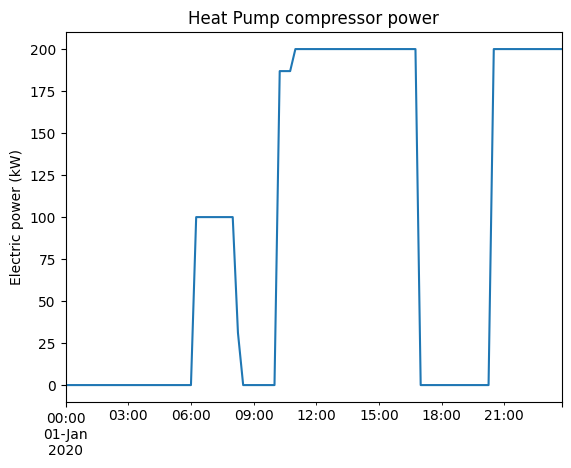

In [143]:
res_df.data_source.loc['air_water_heat_pump'].df.p_comp_kw.plot()
plt.title("Heat Pump compressor power")
plt.ylabel("Electric power (kW)")
plt.show()

The gas boiler will provide power to the demand only when the heat pump reaches its maximum power

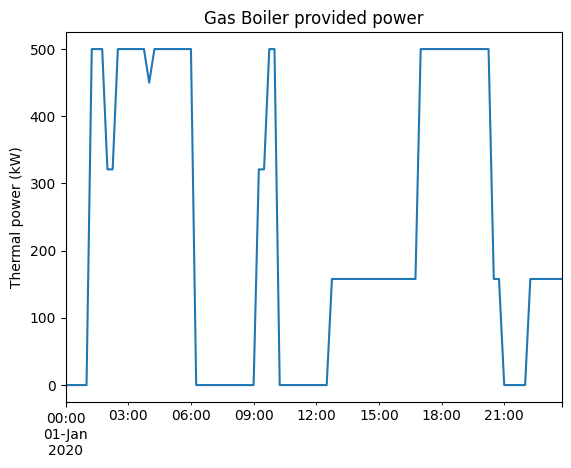

In [144]:
res_df.data_source.loc['gas_boiler'].df.q_kw.plot()
plt.title("Gas Boiler provided power")
plt.ylabel("Thermal power (kW)")
plt.show()

The heat demand of the consumer is then fully met (uncovered demand < $10^{-13}$ kW)

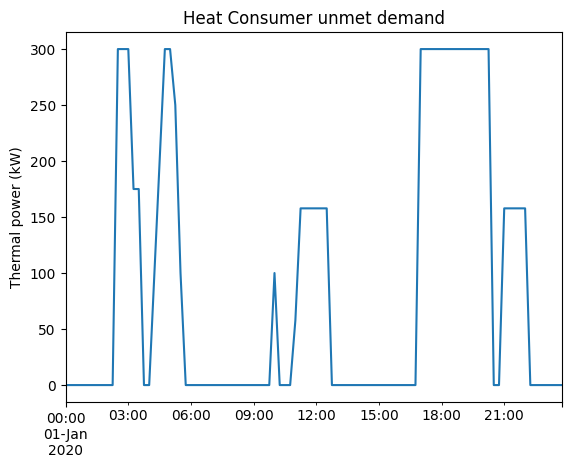

In [145]:
res_df.data_source.loc['heat_consumer'].df.q_uncovered_kw.plot()
plt.title("Heat Consumer unmet demand")
plt.ylabel("Thermal power (kW)")
plt.show()